In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/nikko/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------

star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)

Class Distribution:
class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: proportion, dtype: float64


In [ ]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")

In [4]:
import torch
torch.cuda.empty_cache()

if os.path.exists('trained_models/stacking_clf_index_NOz.pkl'):
    stacking_clf = joblib.load('trained_models/stacking_clf_index_NOz.pkl')
    print("Stacking Classifier caricato da disco")
else:
    stacking_clf = sc.train_stacking(X_train, y_train, X_val, y_val, n_jobs=2)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(stacking_clf, 'trained_models/stacking_clf_index_NOz.pkl')
    print("Stacking Classifier trained and saved")

Stacking Classifier caricato da disco


In [5]:
if os.path.exists('trained_models/voting_clf_index_NOz.pkl'):
    voting_clf = joblib.load('trained_models/voting_clf_index_NOz.pkl')
    print("Voting Classifier caricato da disco")
else:
    voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(voting_clf, 'trained_models/voting_clf_index_NOz.pkl')
    print("Voting Classifier trained and saved")

# for m in (train_m, val_m):
#         print(
#             f"  [{m['dataset']}] Acc={m['accuracy']:.2f}%  "
#             f"P={m['precision']:.2f}  R={m['recall']:.2f}  F1={m['f1']:.2f}"
#         )

Voting Classifier caricato da disco


In [ ]:
import torch
from stellar_classification.models.network import SimpleNN

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

if os.path.exists('trained_models/nn_model_index_NOz.pth'):
    nn_model = SimpleNN(input_size, num_classes)
    nn_model.load_state_dict(torch.load('trained_models/nn_model_index_NOz.pth'))
    nn_model.eval()
    print("NN caricata da disco")
else:
    nn_model = sc.train_neural( 
        train_loader=train_loader,
        val_loader=val_loader,
        input_size=input_size,
        num_classes=num_classes,
        num_epochs=10,
        lr=0.001
    )
    torch.save(nn_model.state_dict(), 'trained_models/nn_model_index_NOz.pth')
    print("NN trained nad saved")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)
    
nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)


In [ ]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/voting_matrix_index_NOz')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/staking_matrix_index_NOz')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network', save_path='/home/nikko/Immagini/res/conf_matrix/NN_matrix_index_NOz')


In [ ]:
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/voting_perm_index_NOz.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/stacking_perm_index_NOz.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 



AttributeError: '_Voting' object has no attribute 'feature_importances_'

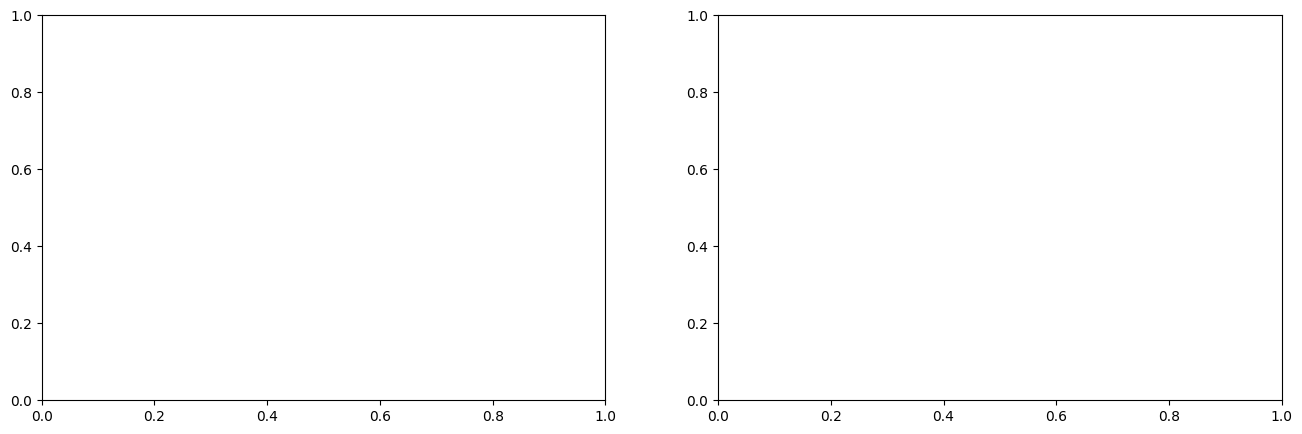

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_feature_importance(
    voting_clf,
    feature_names=feature_names,
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    n_jobs=2,
    ax=ax[0],
    title='Feature Importance - Voting Classifier'
)

sc.plot_feature_importance(
    stacking_clf,
    feature_names=feature_names,
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    n_jobs=2,
    ax=ax[1],
    title='Feature Importance - Stacking Classifier'
)

plt.tight_layout()
plt.show()


In [ ]:
# classify(7)

In [ ]:
# print(star.type())